# Cluster Membership Tracking (first few simple metrics)

In this notebook we compute some simple metrics on the cluster membership stability. Previously we have fixed the number of clusters and have applied a matching algorithm so that we have labels for clusters in consecutive weeks that are comparable (i.e point x stayed in the same 'cluster').

In [1]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score

# Optimisation packages
from scipy.optimize import linear_sum_assignment

# Parallel processing packages
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Functions & Global info

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24

# Time aggregation
agg_hour_level = 1

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

# Silhouette sample size 
sample_size = 1000

In [5]:
# FUNCTION - build features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/ seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
             log_n_events=pl.col("n_events").log1p(),
             log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
             log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

In [6]:
# Relevant feauture columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

In [7]:
# FUNCTION - process features for clustering 
def cluster_preprocess(features_df,feature_cols,week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    features_week = features_df.filter(pl.col('bucket').is_between(lb,ub))

    X = features_week.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return features_week, X_scaled

In [8]:
# FUNCTION - kmeans 
def fit_kmeans(k, Y, sample_size):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    
    sil = silhouette_score(Y, labels, sample_size=sample_size, random_state=123)
    ch  = calinski_harabasz_score(Y, labels)   
    db  = davies_bouldin_score(Y, labels)    
    
    return k, sil,ch,db

In [9]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

## Clustering

In [10]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

## Membership Tracking

In [11]:
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

## Retention Rates

In [12]:
retention_rates = []

for week in range(1,n_weeks):

    labels_curr = aligned_labels[week]['labels_curr']
    labels_next =aligned_labels[week]['labels_next']

    retention_rates.append(np.mean(labels_curr == labels_next))

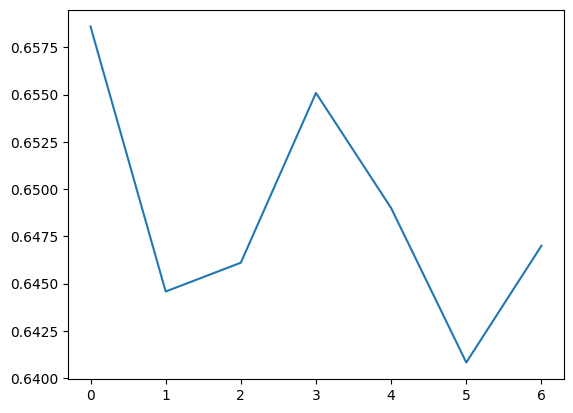

In [13]:
plt.plot(retention_rates)

## Where the cluster members are going

In [20]:
# %%
# Transition matrix per week-pair, plus cluster sizes
transition = np.zeros((n_weeks - 1, k, k))
src_sizes  = np.zeros((n_weeks - 1, k), dtype=int)   # cluster sizes in week w
dst_sizes  = np.zeros((n_weeks - 1, k), dtype=int)   # cluster sizes in week w+1

for week in range(1, n_weeks):
    labels_curr = aligned_labels[week]['labels_curr']
    labels_next = aligned_labels[week]['labels_next']

    C = np.zeros((k, k))
    np.add.at(C, (labels_curr, labels_next), 1)
    row_sums = C.sum(axis=1, keepdims=True)
    transition[week - 1] = np.divide(C, row_sums, out=np.zeros_like(C), where=row_sums > 0)

    src_sizes[week - 1] = C.sum(axis=1).astype(int)
    dst_sizes[week - 1] = C.sum(axis=0).astype(int)

In [21]:
# %%
for week in range(1, n_weeks):
    print(f"week {week} -> {week + 1}   (rows = from, cols = to)")
    print(np.round(transition[week - 1], 3))
    print("from sizes (week w):   ", src_sizes[week - 1], " cluster 0,1,2")
    print("to sizes   (week w+1): ", dst_sizes[week - 1])
    print()

week 1 -> 2   (rows = from, cols = to)
[[0.729 0.27  0.001]
 [0.473 0.525 0.002]
 [0.033 0.043 0.925]]
from sizes (week w):    [386162 221133   8329]  cluster 0,1,2
to sizes   (week w+1):  [386427 220597   8600]

week 2 -> 3   (rows = from, cols = to)
[[0.756 0.244 0.001]
 [0.552 0.447 0.002]
 [0.052 0.039 0.909]]
from sizes (week w):    [389175 229319   8030]  cluster 0,1,2
to sizes   (week w+1):  [421037 197553   7934]

week 3 -> 4   (rows = from, cols = to)
[[0.528 0.471 0.001]
 [0.303 0.696 0.001]
 [0.04  0.022 0.938]]
from sizes (week w):    [199890 425728   8059]  cluster 0,1,2
to sizes   (week w+1):  [235049 390541   8087]

week 4 -> 5   (rows = from, cols = to)
[[0.931 0.027 0.042]
 [0.001 0.717 0.283]
 [0.002 0.455 0.543]]
from sizes (week w):    [  8997 437966 263442]  cluster 0,1,2
to sizes   (week w+1):  [  9115 434018 267272]

week 5 -> 6   (rows = from, cols = to)
[[0.946 0.035 0.019]
 [0.002 0.523 0.475]
 [0.001 0.281 0.718]]
from sizes (week w):    [ 11060 265502 432921

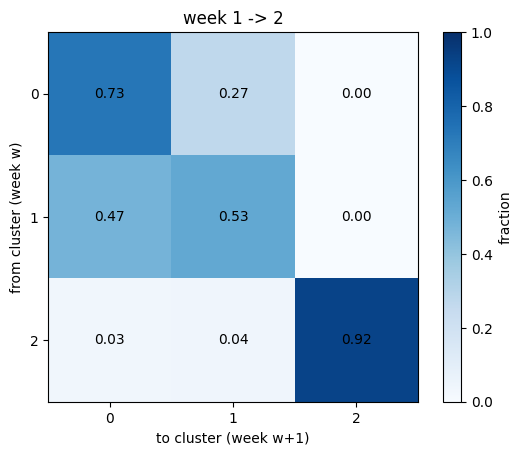

In [22]:
# %%
w = 1  # pick a pair
plt.imshow(transition[w - 1], vmin=0, vmax=1, cmap='Blues')
plt.colorbar(label='fraction')
plt.xlabel('to cluster (week w+1)')
plt.ylabel('from cluster (week w)')
plt.xticks(range(k)); plt.yticks(range(k))
for i in range(k):
    for j in range(k):
        plt.text(j, i, f"{transition[w - 1, i, j]:.2f}", ha='center', va='center')
plt.title(f'week {w} -> {w + 1}')
plt.show()

- **User tracking**: can track what users typically change (incorporate time into this)

- **Initial results**: Larger aggregation levels are more stable in terms of the retention rate

- **Full Matrix**: The rows tells us where the cluster members go , the columns tell us where the clusters are coming from

- **Distance based**: Can align the cluster by distance instead of membership overlap

### Landscape of Cluster Evolution Frameworks

**Membership-Based Tracking (The MONIC Family)**:

1) MONIC (2006):
2) MEC (Monitoring Clusters' Transitions):

**Evolutionary Clustering (The Smoothness Approach)**
1) Chakrabarti’s Framework (2006):

**Spatiotemporal & Density-Based Tracking**
1) Moving Cluster Frameworks:

The mover-stayer (MS) model is a statistical extension of the standard Markov chain model used in economics, sociology, and healthcare to account for unobserved heterogeneity. It divides a population into two distinct, unobservable latent groups: "stayers" who remain in their initial state forever, and "movers" whose transitions follow a standard Markov process.